In [2]:
"""
Imports here
"""
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import numpy as np
import random as rd
import Helper as hp


# NK Model
This is a notebook to help me visualize and work through Stuart Kaufman's *The Origins of Order: Self-Organization and Selection in Evolution*

I will be starting with some generation of NK models, and some verification of claims made by Kaufman about the NK models. 

For the NK model we will want *eventually* to generate a topological map of the fitness landscape, for simplicity of modelling we will be working with the 2 allele toy problem variant.

The NK Model has the following parameters:
- **Necessary**
    - $N$: refers to the number of parts of the system (this can be genes, amino acids in a protein etc)
        - given this the set of total possible genotypes in the ensemble is $2^{N}$ (for the 2 allele toy varient, for any given A it is $A^{N}$) 
    - $K$: refers to the number of epistatic interactions between the parts, that is when assessing the fitness of a given part, what is the average number of other parts that factor into and impact the fitness of the currently considered part
        - this is a point of distinction for the NK model from standard population genetics approaches which confer that each gene contributes independently to the overall fitness (the *N-Locus two-allele additive fitness model*)
        - prior attempts to explain these epistatic interactions include the *multiplicative fitness* model, where genes multiply effects
            - however this approach does not adequately cover the true scope of potential epistatic interactions
            - therefore we will appraoch the modelling from the perspective of trying to capture the statistical features of the range of epistatic interactions by capturing the consequences with a random fitness function
    - $w_{i}$: given assignment of K relevant locus to each gene $i \in N$, we can then assign a list of random weights $w_i \in [0,1]$ for each combination of the $K + 1$ epistatically linked loci. The number of such combinations (that is the length of list of weights for each locus) will be $2^{K+1}$ (for our purposes this list will be the length of the whole ensemble, so we have an easier time managing the weights calculation).

- **Optional**
    - **A**: refers to the number of Alleles for each $N$ part. For simplicity will hold this at 2 alleles so that modelling is possible
    - **I**: this specifies how the $K$ genes are distributed across the $N$ genes (that is the mapping of the interactions) -> Kaufman says this isn't necessary (*verify*)
    - **D**: the dimensionality of the genotype space - reflects the number of 1-mutant neighbours each genotype has in the space ($N(A-1)$ and in the case of our toy scope $N$)

And the following properties/outcomes:
- $W$: this is the overall fitness of the entire genotype defined with the function $W = \frac{1}{N}\displaystyle\sum^{N}_{i=1}w_i$

In [3]:
# Find new one hammond moves from a given position
def new_one_hammonds(genotype:list,
                     seen: list):
    one_hammonds = []
    for i in range(len(genotype)):
        temp = genotype.copy()
        if genotype[i] == 1:
            temp[i] = 0
        elif genotype[i] == 0:
            temp[i] = 1
        value_tuple = tuple(temp)
        if value_tuple not in seen: 
            one_hammonds.append(temp)
            seen.append(value_tuple)
    return one_hammonds, seen


#we need to generate a smaller ensemble for testing, given an initial state as a number, generate subensemble contasining it and all it's neighbours for rounds steps
def generate_ensemble_slice(start: list,
                            N: int,
                            K: int,
                            A: int = 2,
                            rounds: int = 10,
                            players: int = 10):
    ensemble = {}
    ensemble[0] = start 
    rounds_counter = 0
    seen = []
    while rounds_counter < rounds:
        lens = len(ensemble)
        lens2= len(seen)
        copy_ensemble = ensemble.copy()
        for key, value in copy_ensemble.items():
            one_hammonds, seen = new_one_hammonds(value, seen)
            for j in one_hammonds:
                ensemble[len(ensemble)] = j
        rounds_counter+=1        
    return ensemble


# The function below generates weights. It can either generate entirely random weights for each gene i in N for each ensemble, or it can generate weights preserving the mapping defined in assign_neighbours
# this will return the weight matrix for the ensemble.
def generate_weights(N: int,
                     K: int,
                     ensemble: dict,
                     A: int = 2):
    weights = {}
    K_loci = hp.assign_neighbours(N,K)
    for i in range(N):
        weight_i = []
        neighbours = K_loci[i]
        neighbour_set = {}
        for j in ensemble.keys():
            genotype = ensemble[j]
            temp = []
            present = False
            for n in neighbours:
                temp.append(genotype[n])
            for key, val in neighbour_set.items():
                if val == temp:
                    weight_i.append(key)
                    present = True
            if present == False:
                weight = rd.random()
                neighbour_set[weight] = temp
                weight_i.append(weight)
            elif present == True:
                present = False
            weights[i] = weight_i
    return weights

#The following function calculates the total genotype fitness sum and returns a dictionary containing all the genotypes and their fitness scores
def calculate_fitness(weights: dict,
                     ensemble: dict):
    genotype_fitness = []
    for i in ensemble.keys():
        fitness = 0
        genotype = ensemble[i]
        for j in range(len(weights)):
            fitness += weights[j][i]
        genotype_fitness.append(fitness)
    return genotype_fitness
     

# Fitness Landscapes Given Different K values
Now that I spent a whole evening setting the above up, we are ready to do visualize all of the great fitness graphs that Kaufman has in store for us. 
The code below is testing out some different methods of visualization. 

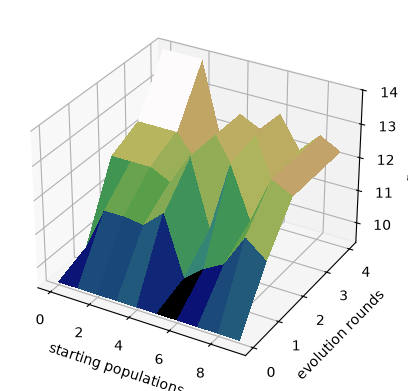

[[array([0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0])
  array([0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0])
  array([0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0])
  array([0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0])
  array([0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0])]
 [array([0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0])
  array([0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0])
  array([0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0])
  array([0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0])
  array([0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0])]
 [array([0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0])
  array([0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0])
  array([0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0])
  array([0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0])
  array([0, 0, 0, 

In [7]:
def starting_ensemble(N: int,
                      K: int,
                      A: int = 2,
                      rounds: int = 10,
                      players: int = 10):
    random_genome_number = rd.randint(0,A**N)
    start_genome = hp.generate_bit_strings(random_genome_number, N, A) 
    ensemble = generate_ensemble_slice(start_genome, N, A, rounds = rounds, players = players)
    weights = generate_weights(N, K, ensemble, A)
    fitness = calculate_fitness(weights, ensemble)
    return start_genome, ensemble, fitness



# Here we are gonna try generating a set of one mutant walks from a single genotype and graphing their fitness changes 
# => hopefully this should give us a clearer slice of the dynamics of the fitness landscape (assuming ergodicity) 

    
def one_mutant_scape(N: int,
                     K: int,
                     A: int = 2,
                     rounds:   int = 10,
                     players:  int = 10):

    
    
    # here we initialize the starting genome from which to perform walks and the fitness/paths arrays to store the process
    start_genome, ensemble, fitnesses = starting_ensemble(N, K, A, rounds, players)
    current_genome                    = np.zeros(players, dtype=object)
    fitness_array                     = np.zeros((rounds, players))
    evolution_array                   = np.zeros((players, rounds), dtype=object)

    # populate first step into evolution array, and first fitness in fitness array
    for p in range(players):
        fitness_array[0][p]   = fitnesses[0]
        current_genome[p]     = start_genome.copy()
        evolution_array[p][0] = current_genome[p]
    round_tracker   = 0
    
    while round_tracker < rounds-1:
        round_tracker+=1
        good_directions = {}
        for i in range(players):
            # make+test a generate good directions function
            one_hammonds = hp.all_one_hammonds(current_genome[i])
            hammond_keys = hp.hammonds_keys(one_hammonds, ensemble)
            good_directions.setdefault(i, [])
            good_directions[i] = hp.good_neighbours(hammond_keys, ensemble, fitnesses, fitness_array[round_tracker-1][i])
            #print(good_directions)
            if len(good_directions[i]) == 0:
                fitness_array[round_tracker][i] = fitness_array[round_tracker-1][i]
                evolution_array[i][round_tracker] = evolution_array[i][round_tracker-1]
            elif len(good_directions[i]) > 0:  
                step_random = rd.randint(0,len(good_directions[i])-1)
                genome, fitness = good_directions[i][step_random]
                fitness_array[round_tracker][i] = fitness
                evolution_array[i][round_tracker] = genome
                current_genome[i] = genome
    return fitness_array, evolution_array

def generate_onescape(fitness_array: list,
                   evolution_array: list):
    #z = fitness_array.transpose()
    z = fitness_array
    x = []
    y = []
    x_name = str(evolution_array[0][0])
    for i in range(len(evolution_array)):
        x.append(i)
        if i == 0:
            for j in range(len(evolution_array[i])):
                y.append(j)
        
    x, y = np.meshgrid(x, y)

    # Set up plot
    fig, ax = plt.subplots(subplot_kw=dict(projection='3d'))
    ax.set_xlabel('starting populations')
    ax.set_ylabel('evolution rounds')
    ax.set_zlabel('fitness')
    
    #ls = LightSource(180, 45)
    # To use a custom hillshading mode, override the built-in shading and pass
    # in the rgb colors of the shaded surface calculated from "shade".
    #rgb = ls.shade(z, cmap=plt.colormaps["gist_earth"], vert_exag=0.1, blend_mode='overlay')
    #surf = ax.plot_surface(x, y, z, rstride=1, cstride=1, facecolors=rgb, linewidth=0, antialiased=False, shade=False)
    surf = ax.plot_surface(x, y, z, rstride=1, cstride=1, cmap=plt.colormaps["gist_earth"], linewidth=0, antialiased=False, shade=False)

    plt.show()


        
    



N = 20
K = 19
A = 2
r = 5
p = 10




#print(ensemble)
#print(fitness)
#print(fitness_changes)

boob, ass = one_mutant_scape(N,K,A, rounds = r, players = p)
boobs = generate_onescape(boob, ass)
print(ass)
            